# Wine rating with the use of Elastic Net Regression

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

def fetch_uci_data(id: int):
    """
    Function to return features (X) and response variable (y) from datasets 
    from the UCI ML Repository.

    Parameters
    ----------
    id: int
        Identifying number for the dataset

    Returns
    ----------
    X: df
        Dataframe with features 
    y: array-like (n_observations,)
        Array-like object with length equal to the number of observations  
    """
    dataset = fetch_ucirepo(id=id) 

    features = pd.DataFrame(dataset.data.features)
    response = pd.DataFrame(dataset.data.targets)
    df = pd.concat([features, response], axis=1)

    # Print variable information
    print('Variable Information')
    print('--------------------')
    print(dataset.variables)

    return(df)

In [2]:
from data_source import get_statistics, scale_data, separate_data
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
df = fetch_uci_data(id=186)

Variable Information
--------------------
                    name     role         type demographic  \
0          fixed_acidity  Feature   Continuous        None   
1       volatile_acidity  Feature   Continuous        None   
2            citric_acid  Feature   Continuous        None   
3         residual_sugar  Feature   Continuous        None   
4              chlorides  Feature   Continuous        None   
5    free_sulfur_dioxide  Feature   Continuous        None   
6   total_sulfur_dioxide  Feature   Continuous        None   
7                density  Feature   Continuous        None   
8                     pH  Feature   Continuous        None   
9              sulphates  Feature   Continuous        None   
10               alcohol  Feature   Continuous        None   
11               quality   Target      Integer        None   
12                 color    Other  Categorical        None   

               description units missing_values  
0                      NaN  None       

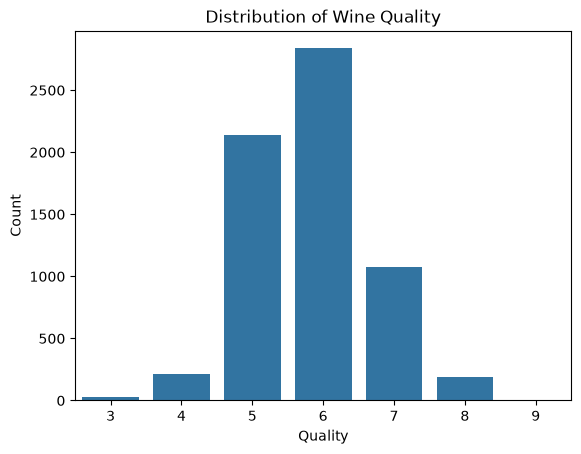

In [4]:
sns.countplot(data=df, x='quality')
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

In [5]:
df['quality'].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [7]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
get_statistics(df)

-------------------------
Descriptive Statistics
-------------------------
          fixed_acidity  volatile_acidity  citric_acid  residual_sugar    chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density           pH    sulphates      alcohol      quality
count       6497.000000       6497.000000  6497.000000     6497.000000  6497.000000          6497.000000           6497.000000  6497.000000  6497.000000  6497.000000  6497.000000  6497.000000
mean           7.215307          0.339666     0.318633        5.443235     0.056034            30.525319            115.744574     0.994697     3.218501     0.531268    10.491801     5.818378
std            1.296434          0.164636     0.145318        4.757804     0.035034            17.749400             56.521855     0.002999     0.160787     0.148806     1.192712     0.873255
min            3.800000          0.080000     0.000000        0.600000     0.009000             1.000000              6.000000     0.987110     2.720000     

In [9]:
import utils
sns.set_theme(style='whitegrid')

def categorize_quality(value):
    if 0<= value <= 3:
        return 0
    elif 4 <= value <= 6:
        return 1 
    else:
        return 2 

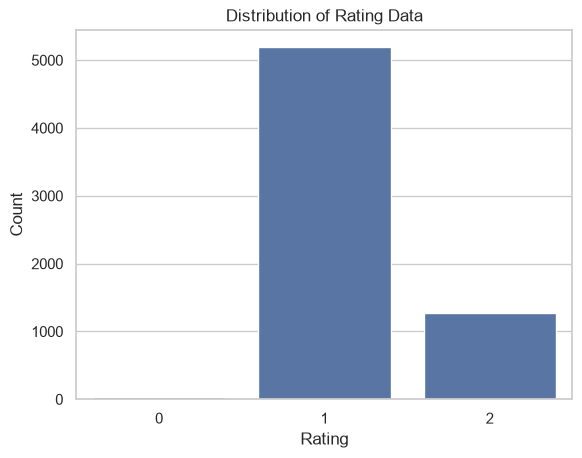

In [10]:
df['rating'] = df['quality'].apply(categorize_quality)
df['rating'] = df['rating'].astype('category')
sns.countplot(data=df, x='rating')
plt.title('Distribution of Rating Data')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

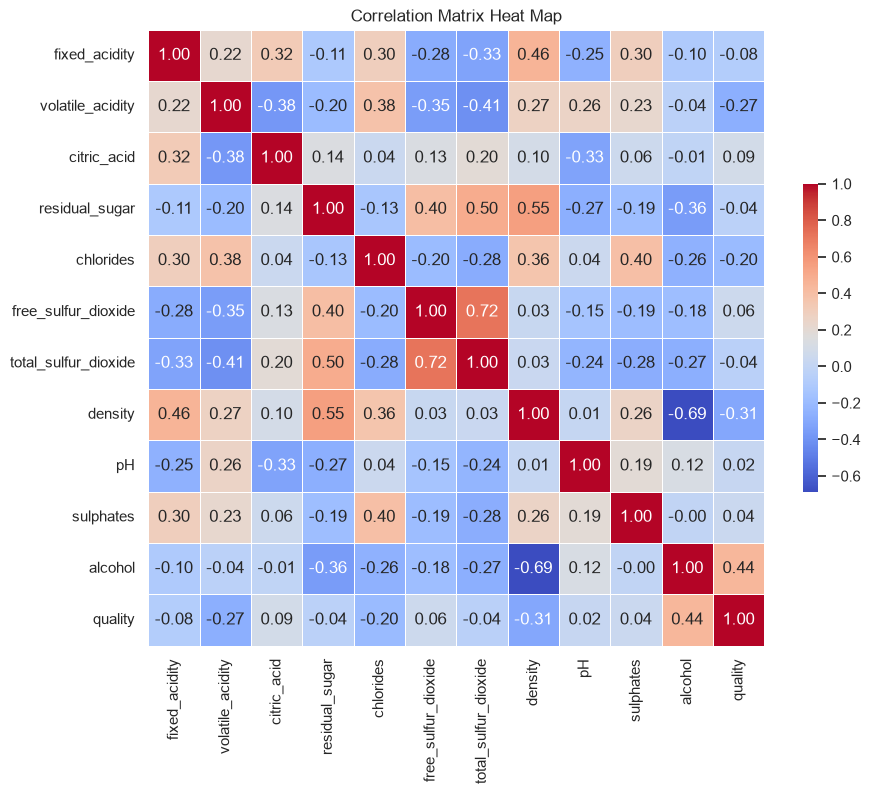

In [11]:

utils.gen_corr_matrix_hmap(df)

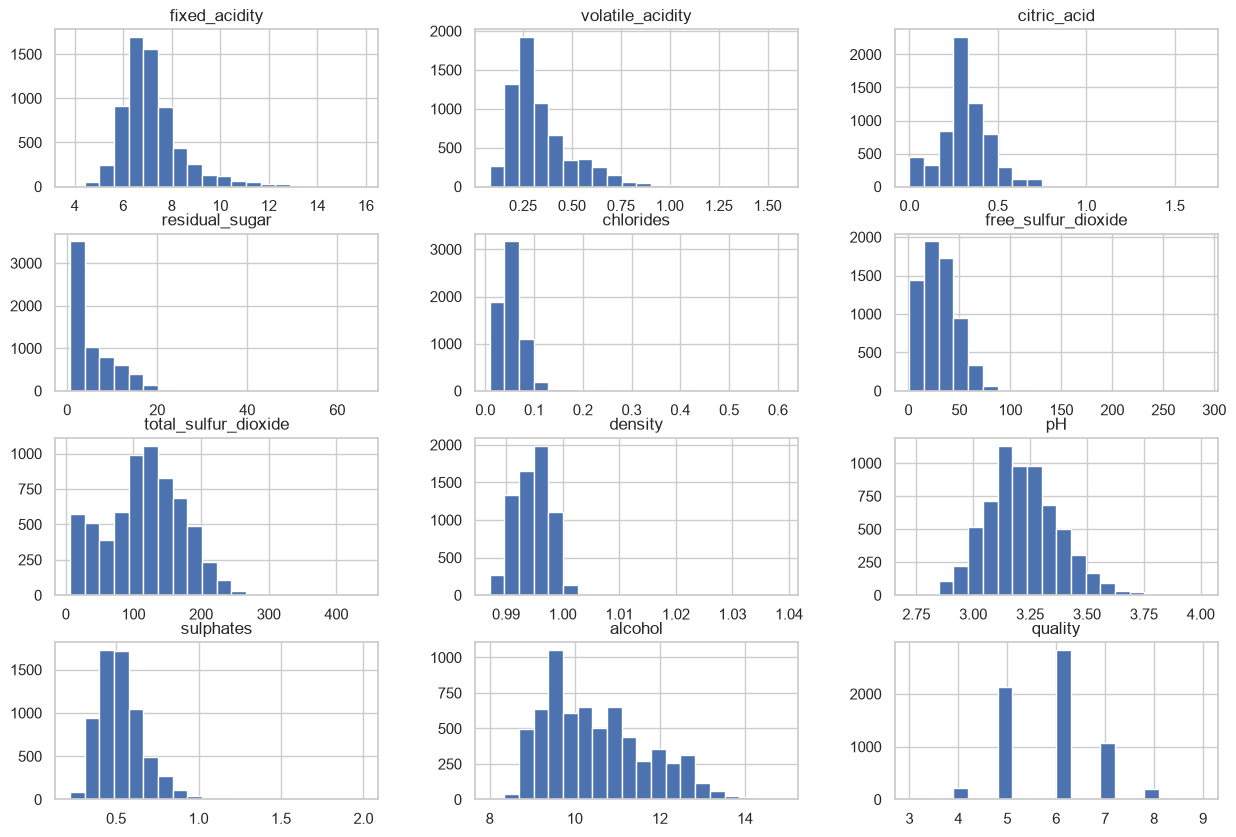

In [12]:
utils.gen_histograms(df)

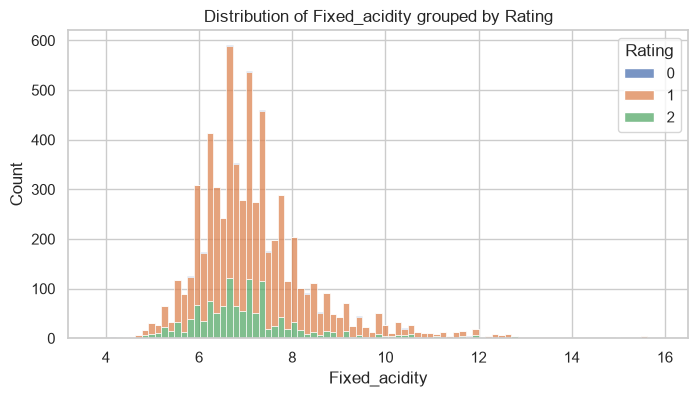

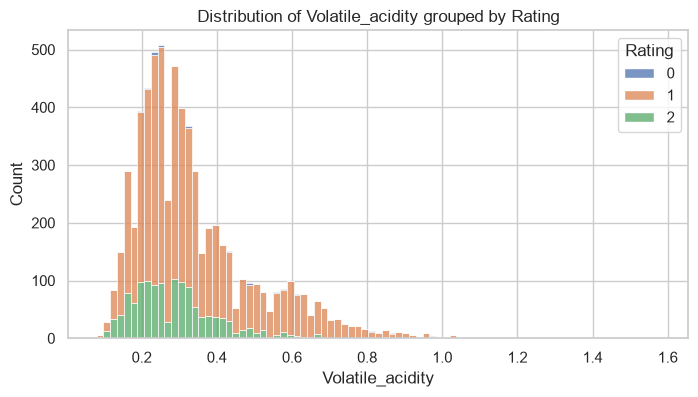

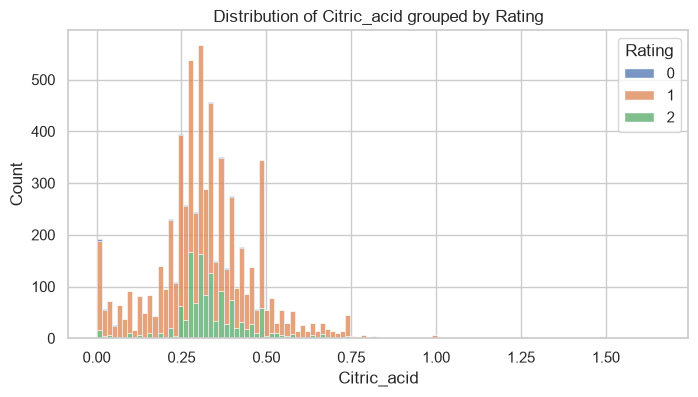

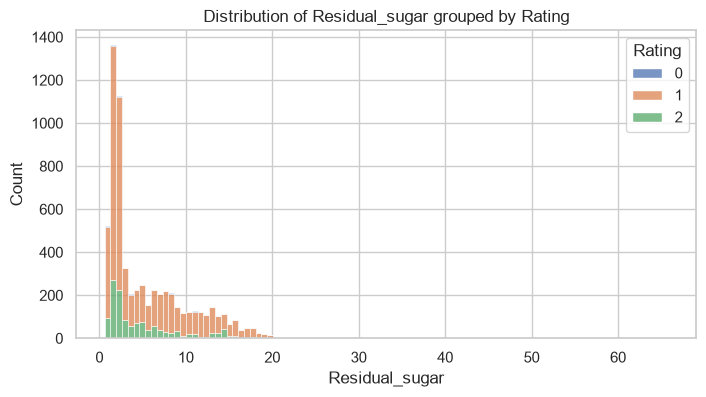

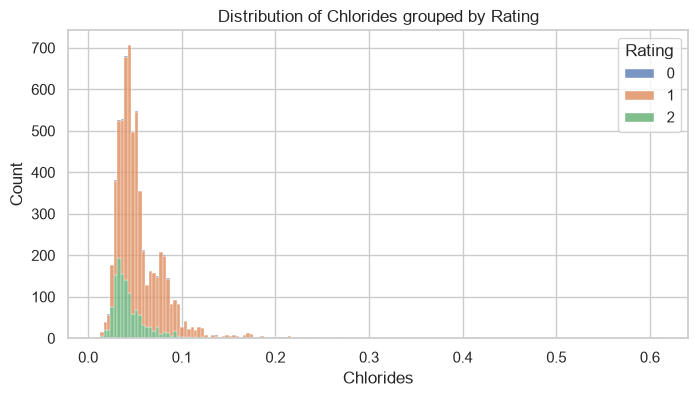

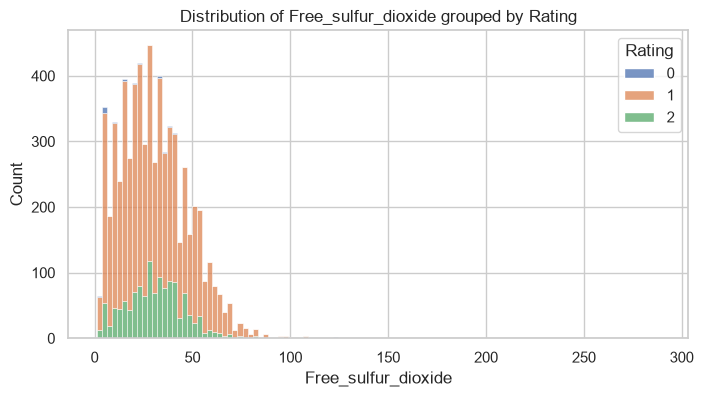

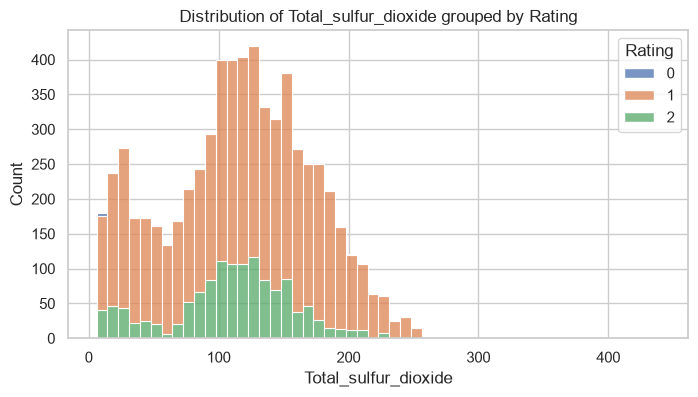

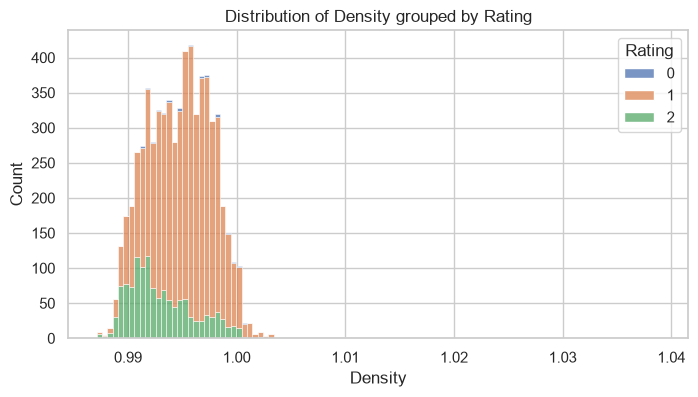

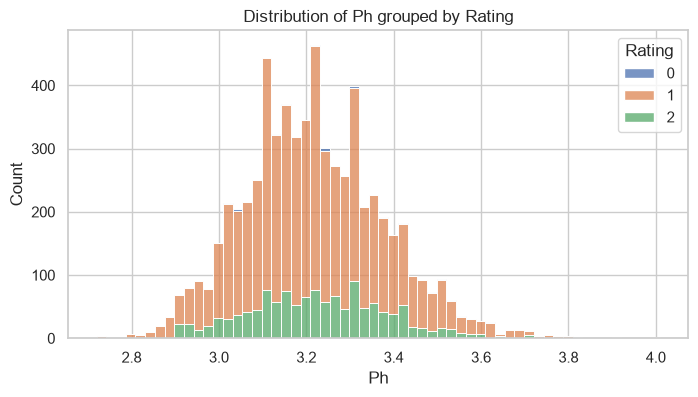

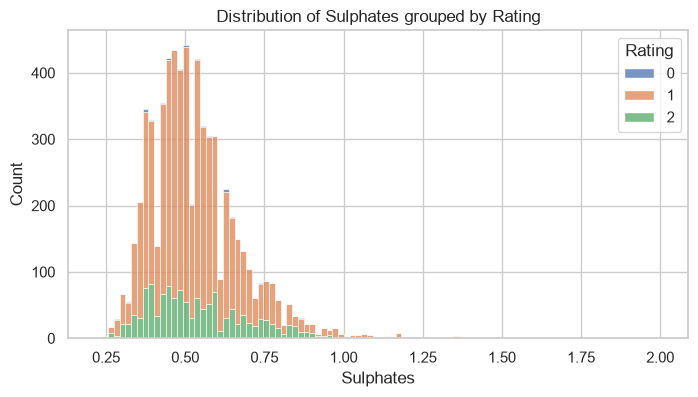

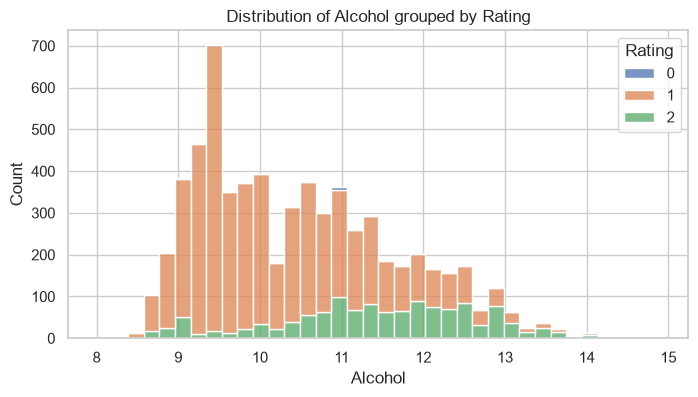

In [13]:
utils.gen_histograms_by_category(df,'rating')

In [14]:
get_statistics(df)

-------------------------
Descriptive Statistics
-------------------------
          fixed_acidity  volatile_acidity  citric_acid  residual_sugar    chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density           pH    sulphates      alcohol      quality
count       6497.000000       6497.000000  6497.000000     6497.000000  6497.000000          6497.000000           6497.000000  6497.000000  6497.000000  6497.000000  6497.000000  6497.000000
mean           7.215307          0.339666     0.318633        5.443235     0.056034            30.525319            115.744574     0.994697     3.218501     0.531268    10.491801     5.818378
std            1.296434          0.164636     0.145318        4.757804     0.035034            17.749400             56.521855     0.002999     0.160787     0.148806     1.192712     0.873255
min            3.800000          0.080000     0.000000        0.600000     0.009000             1.000000              6.000000     0.987110     2.720000     

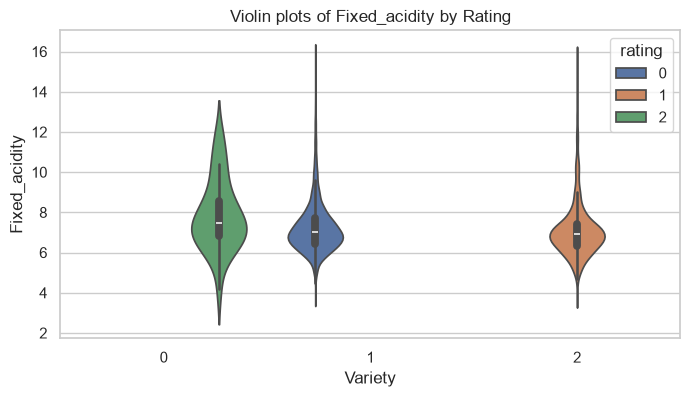

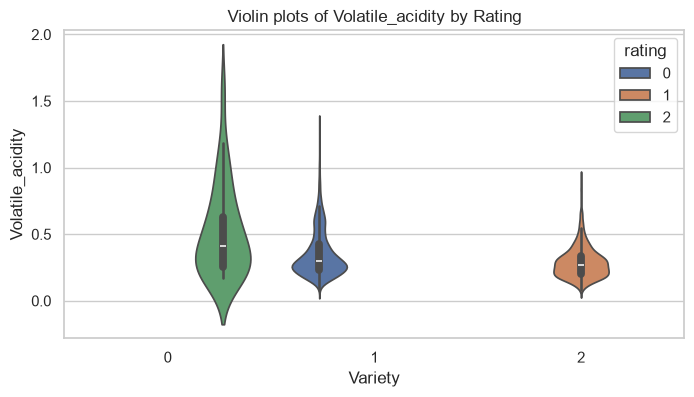

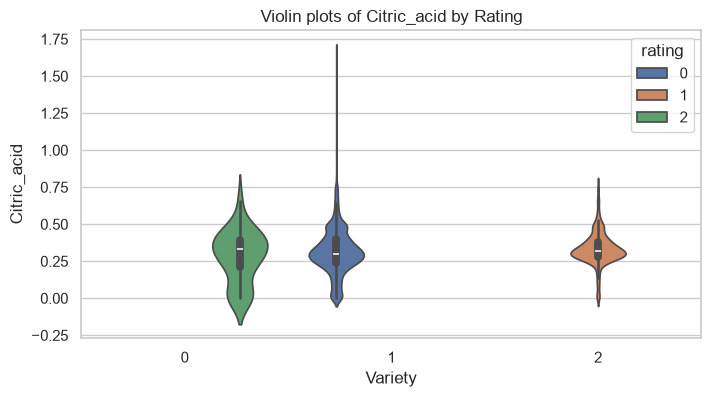

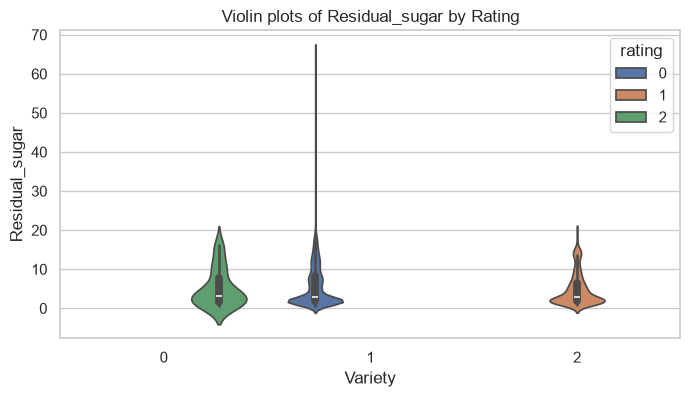

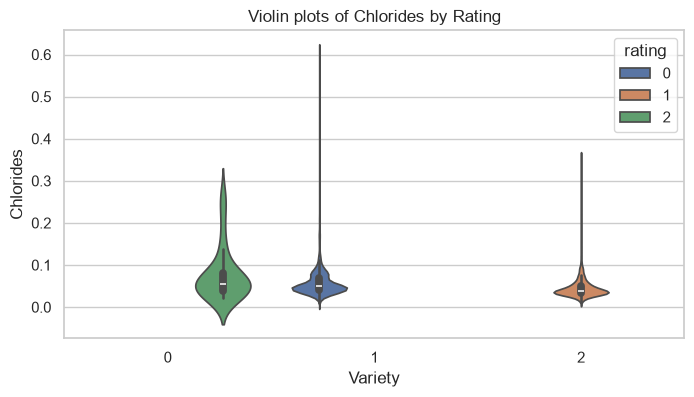

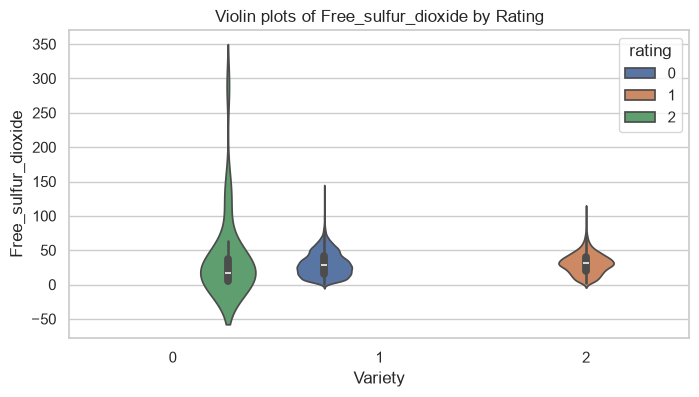

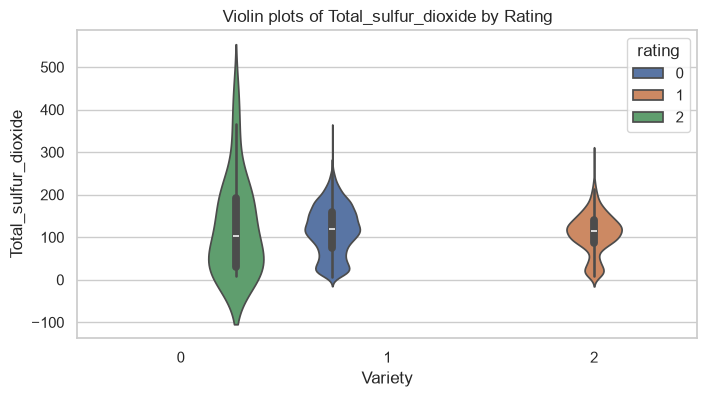

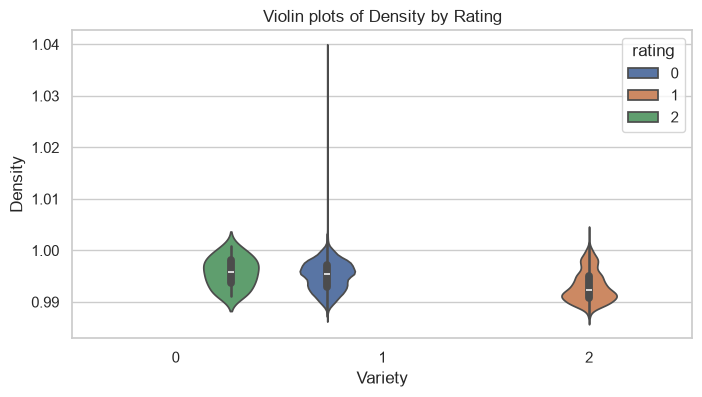

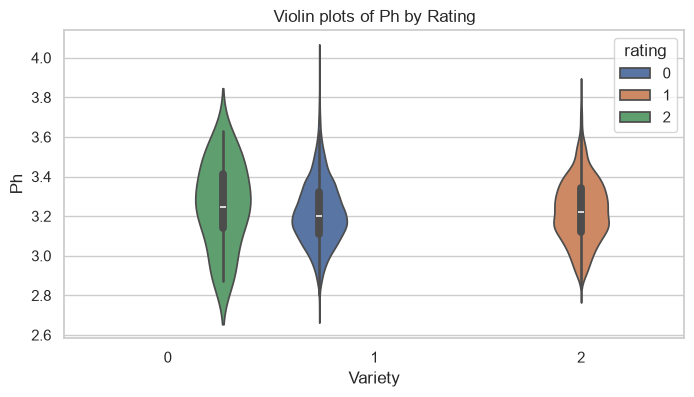

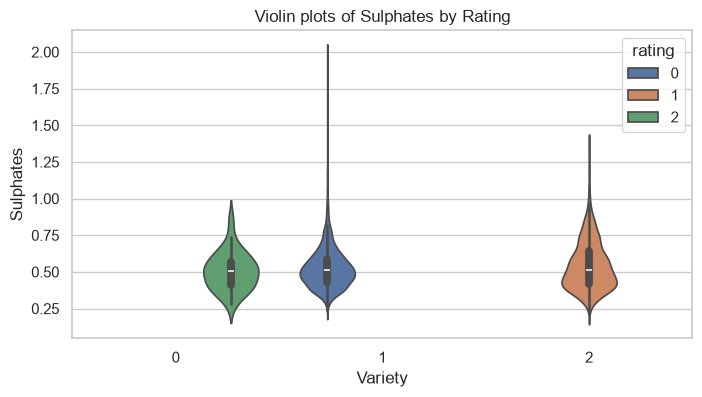

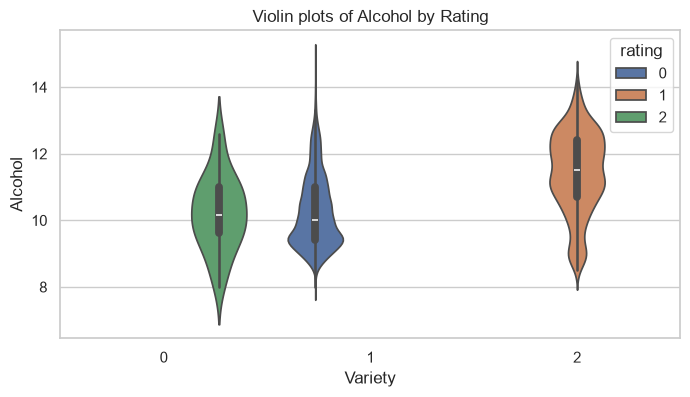

In [15]:
utils.gen_violin_by_category(df, 'rating')

In [16]:
df_scaled = scale_data(df)
df_encoded = pd.get_dummies(df_scaled, columns=['quality', 'rating'])
X, y = separate_data(df_encoded, 'alcohol')
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state=0)
from sklearn.linear_model import ElasticNet, ElasticNetCV

elastic_net_cv = ElasticNetCV(cv=5, random_state=1)
elastic_net_cv.fit(X_train, y_train)

print(f'Best Alpha: {elastic_net_cv.alpha_}')
print(f'Best L1 Ratio:{elastic_net_cv.l1_ratio_}')




elastic_net_pred = elastic_net_cv.predict(X_test)

mse = mean_squared_error(y_test, elastic_net_pred)
r_squared = elastic_net_cv.score(X_test, y_test)

print(f'Mean Squared Error: {mse}')
print(f'R-squared value: {r_squared}')

Best Alpha: 0.0013637974514517561
Best L1 Ratio:0.5
Mean Squared Error: 0.2999434011721803
R-squared value: 0.7142939720612289
